# Titanic
En este proyecto vamos a utilizar modelos de clasificación para poder predecir la supervivencia de una persona dada en la situación del titanic.

In [31]:
!pip install -q numpy
!pip install -q matplotlib
!pip install -q pandas
!pip install -q scikit-learn
!pip install -q seaborn

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

data = sns.load_dataset('titanic')

# Estudio y Procesamiento del Dataset

In [33]:
print(f"-----------------------TYPES ------------------------\n {data.dtypes} \n --------------------------------------------------------------------")

-----------------------TYPES ------------------------
 survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object 
 --------------------------------------------------------------------


In [34]:
print(f"-----------------------SAMPLES ------------------------\n {data.head()} \n --------------------------------------------------------------------")

-----------------------SAMPLES ------------------------
    survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True   
 --------------------------------------------------------------------


In [35]:
print(data.isna().sum())

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


Bien, podemos ver que el dataset tiene bastante puntos débiles, en particular:
-   features con valores nulos => `age`, `deck`
-   features redundantes => `who` y `sex`, `pclass` y `class`, `alive` y `survived`
-   features no relacionadas => `embark_town`, `embarked`, `fare` 

Por lo tanto eliminemos aquellas features que no nos sirvan para el modelado, además de definir nuestra variable objetivo `survived`.

In [36]:
x = data.drop(["age","deck","who","class","embark_town","embarked","fare","alive","survived"],axis=1)
y = data["survived"]
print(x)

     pclass     sex  sibsp  parch  adult_male  alone
0         3    male      1      0        True  False
1         1  female      1      0       False  False
2         3  female      0      0       False   True
3         1  female      1      0       False  False
4         3    male      0      0        True   True
..      ...     ...    ...    ...         ...    ...
886       2    male      0      0        True   True
887       1  female      0      0       False   True
888       3  female      1      2       False  False
889       1    male      0      0        True   True
890       3    male      0      0        True   True

[891 rows x 6 columns]


Es importante notar que tenemos algunos features que son categoricos (alone, sex, adult_male) y el resto númericos, es por esto que no podemos simplemente utilizar un modelo para nuestras predicciones, sin embargo podemos separarlas segun su tipo. 

In [37]:
X_train, X_test, Y_train, Y_test = train_test_split(x,y,test_size=.2)

numerical_features = X_train.select_dtypes(include=['number']).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

## Pipelines

Ahora bien, necesitamos poder transformar estos dos tipos de datos a un mismo espacio para que nuestro modelo pueda utilizar toda la información disponible, para esto usamos transformadores. <br>

### Transformación

Lo primero que vamos a hacer es generar los dos transformadores para features categoricas y numericas, después usamos un transformador columna que combina ambos trasnformadores, devolviendo un esquema de valores que nuestro modelo puede utilizar.

In [38]:
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

## Modelo A
Teniendo nuestro dataset procesado podemos pasar a la creación del pipeline, vamos a utilizar un modelo de random forests para las predicciones, además de emplear cross-validation para optimizarlo.

In [39]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=31))
])

param_grid = {
    'classifier__n_estimators': [50,75,100],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split': [2, 5]
}

cv = StratifiedKFold(n_splits=8, shuffle=True)

### Entrenamiento

Ahora pasamos a entrenar el modelo, utilizando la optimización previamente armada para obtener el mejor resultado posible

In [40]:
model = GridSearchCV(estimator=pipeline, param_grid=param_grid, cv=cv, scoring='accuracy', verbose=1)
model.fit(X_train, Y_train)

Fitting 8 folds for each of 18 candidates, totalling 144 fits


GridSearchCV(cv=StratifiedKFold(n_splits=8, random_state=None, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['pclass',
                                                                          'sibsp',
                                                                          'parch']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['sex'])])),
                                       ('classifier',
                                        RandomForestClassifier(random_state=31))]),
             param_grid={'classifier__max_depth': [None, 10, 20],
                         'classifier__min_samples_split': [2, 5],
                         'classifier__n_estimators': [50, 75, 100]},
             scoring='accuracy', verbose=1)

### Predicciones

Teniendo nuestro modelo entrenado obtengamos las predicciones en base a nuestro split de validación

In [41]:
random_forest_y_pred = model.predict(X_test)

### Analisis de Resultados

Por último veamos los resultados obtenidos en las predicciones del modelo optimizado.

In [42]:
print(classification_report(Y_test, random_forest_y_pred))


              precision    recall  f1-score   support

           0       0.77      0.91      0.84       113
           1       0.78      0.55      0.64        66

    accuracy                           0.78       179
   macro avg       0.78      0.73      0.74       179
weighted avg       0.78      0.78      0.77       179



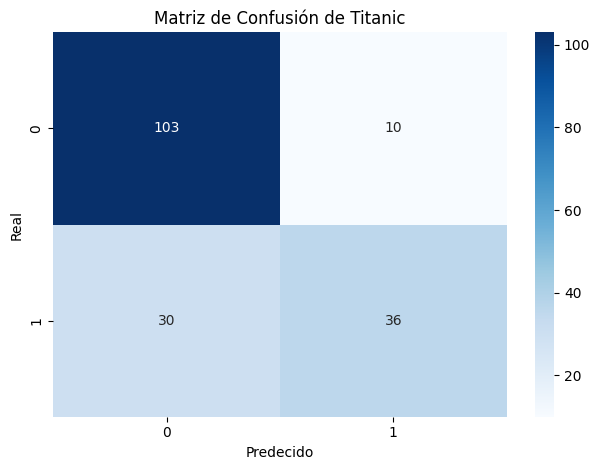

In [43]:

conf_matrix = confusion_matrix(Y_test, random_forest_y_pred)

plt.figure()
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='d')


plt.title('Matriz de Confusión de Titanic')
plt.xlabel('Predecido')
plt.ylabel('Real')

# Show the plot
plt.tight_layout()
plt.show()

In [44]:
feature_importances = model.best_estimator_['classifier'].feature_importances_

# Combine the numerical and one-hot encoded categorical feature names
feature_names = numerical_features + list(model.best_estimator_['preprocessor']
                                        .named_transformers_['cat']
                                        .named_steps['onehot']
                                        .get_feature_names_out(categorical_features))

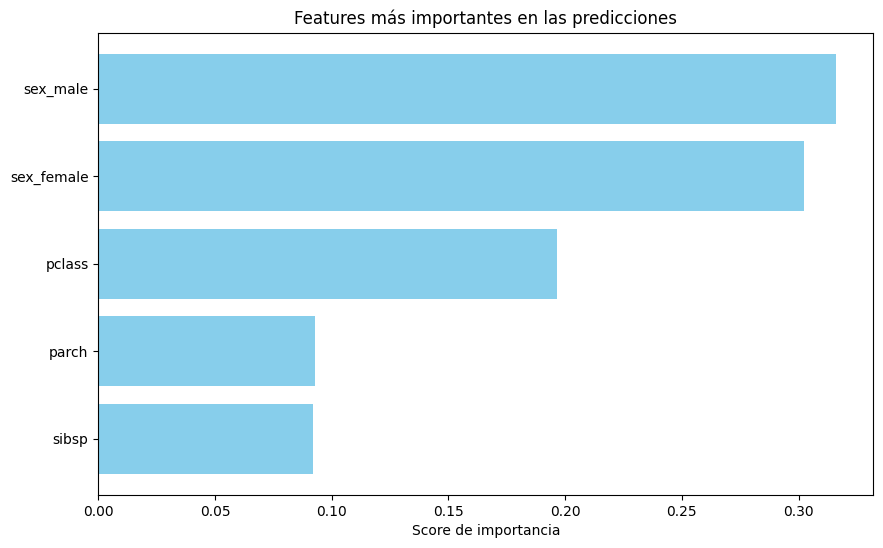


Test set accuracy: 77.65%


In [45]:
importance_df = pd.DataFrame({'Feature': feature_names,
                              'Importance': feature_importances
                             }).sort_values(by='Importance', ascending=False)

# Plotting
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue')
plt.gca().invert_yaxis() 
plt.title('Features más importantes en las predicciones')
plt.xlabel('Score de importancia')
plt.show()

# Print test score 
test_score = model.score(X_test, Y_test)
print(f"\nTest set accuracy: {test_score:.2%}")

## Modelo B

Ahora pasemos a una regresión logística para ver si obtenemos mejores resultados. <br> Gracias al pipeline definido anteriormente podemos actualizar el modelo de forma rápida

In [46]:
pipeline.set_params(classifier=LogisticRegression(random_state=35))

model.estimator = pipeline

logreg_param_grid = {
    'classifier__solver' : ['liblinear'],
    'classifier__penalty': ['l1', 'l2'],
    'classifier__class_weight' : [None, 'balanced']
}

model.param_grid = logreg_param_grid

model.fit(X_train, Y_train)

logistical_regression_y_pred = model.predict(X_test)


Fitting 8 folds for each of 4 candidates, totalling 32 fits


### Analisis de Resultados
Calculemos las métricas de resultados predictivos

In [ ]:
print(classification_report(Y_test, logistical_regression_y_pred))

              precision    recall  f1-score   support

           0       0.80      0.87      0.83       113
           1       0.73      0.62      0.67        66

    accuracy                           0.78       179
   macro avg       0.76      0.74      0.75       179
weighted avg       0.77      0.78      0.77       179



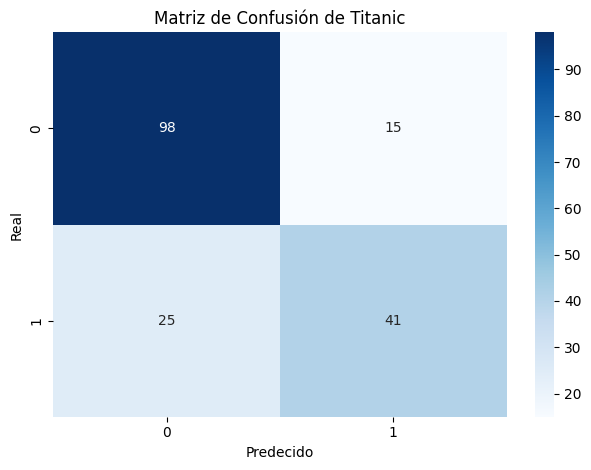

In [48]:

conf_matrix = confusion_matrix(Y_test, logistical_regression_y_pred)

plt.figure()
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='d')


plt.title('Matriz de Confusión de Titanic')
plt.xlabel('Predecido')
plt.ylabel('Real')

# Show the plot
plt.tight_layout()
plt.show()

## Comparación de Resultados
Teniendo el resultado de ambos modelos podemos analizar un poco las diferentes métricas obtenidas para definir cual sería el modelo más apto.

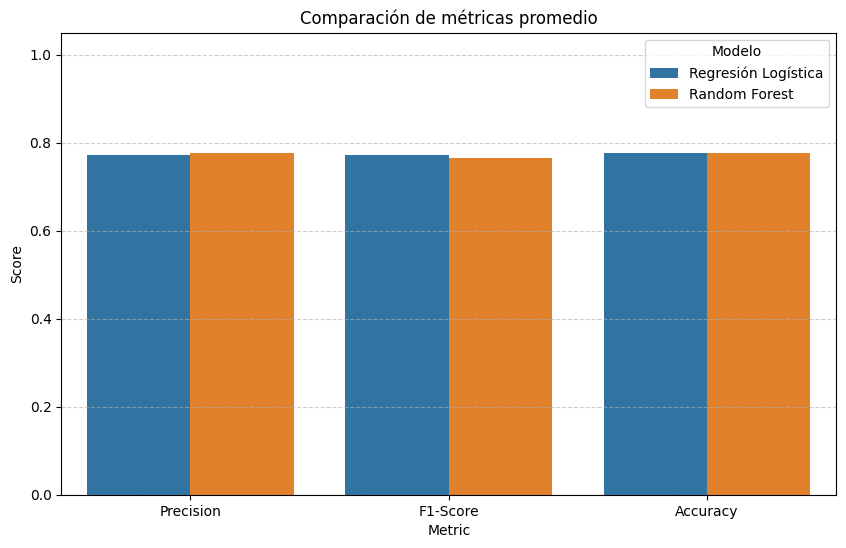

In [62]:
regression_report = classification_report(Y_test, logistical_regression_y_pred, output_dict=True)
forest_report = classification_report(Y_test, random_forest_y_pred, output_dict=True)

plot_data = [
    {'Metric': 'Precision', 'Value': regression_report['weighted avg']['precision'], 'Modelo': 'Regresión Logística'},
    {'Metric': 'F1-Score', 'Value': regression_report['weighted avg']['f1-score'], 'Modelo': 'Regresión Logística'},
    {'Metric': 'Accuracy', 'Value': regression_report['accuracy'], 'Modelo': 'Regresión Logística'},
    
    {'Metric': 'Precision', 'Value': forest_report['weighted avg']['precision'], 'Modelo': 'Random Forest'},
    {'Metric': 'F1-Score', 'Value': forest_report['weighted avg']['f1-score'], 'Modelo': 'Random Forest'},
    {'Metric': 'Accuracy', 'Value': forest_report['accuracy'], 'Modelo': 'Random Forest'}
]

df = pd.DataFrame(plot_data)

plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='Metric', y='Value', hue='Modelo')

plt.title('Comparación de métricas promedio')
plt.ylim(0,1.05)
plt.ylabel('Score')
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

Podemos ver que en general tenemos una performance promedio similar, en este caso quizás podriamos querer investigar que diferencias hay respecto a los errores cometidos. <br>
Esto es particularmente útil en casos donde ciertos errores son mucho mas graves que otros, por ejemplo a la hora de diagnosticar tumores.

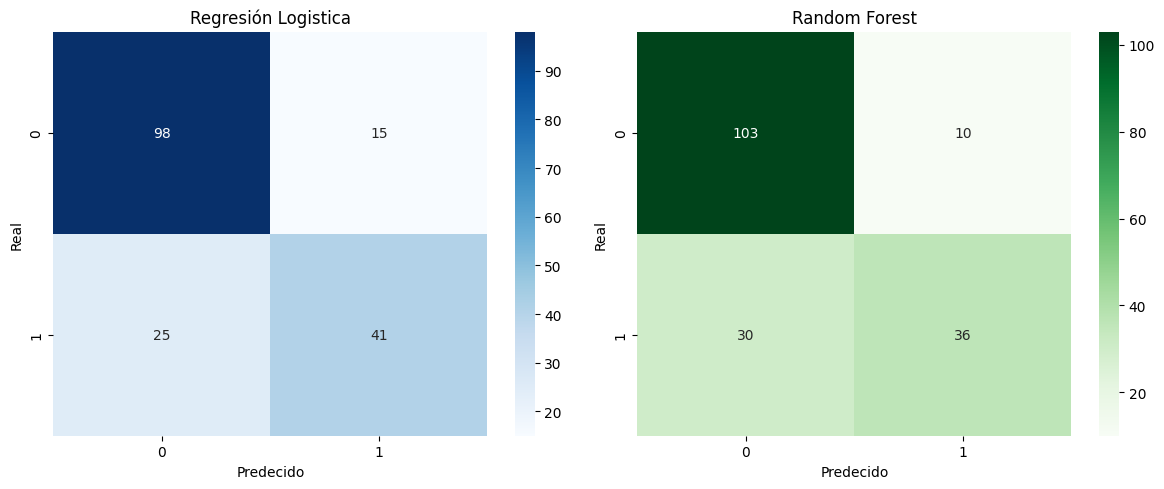

In [64]:

reg_conf_matrix = confusion_matrix(Y_test, logistical_regression_y_pred)
forest_conf_matrix = confusion_matrix(Y_test,random_forest_y_pred)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# First Matrix
sns.heatmap(reg_conf_matrix, annot=True, fmt='g', ax=ax[0], cmap='Blues')
ax[0].set_title('Regresión Logistica')
ax[0].set_xlabel('Predecido')
ax[0].set_ylabel('Real')

# Second Matrix
sns.heatmap(forest_conf_matrix, annot=True, fmt='g', ax=ax[1], cmap='Greens')
ax[1].set_title('Random Forest')
ax[1].set_xlabel('Predecido')
ax[1].set_ylabel('Real')

plt.tight_layout()
plt.show()

En este contexto, predecir que gente no sobrevive a la catastrofe habiendo sobrevivido sería el peor caso posible (supongamos que no se enviarían misiones de rescate para encontrar a dichas personas). <br>Uno podría entonces argumentar que si bien los errores generalizados son similares el modelo de Regresión Logistica es mejor, dado que tiene una menor tendencia a predecir Falsos Negativos (en particular un 2% menos probable).